# Corrosion Rate Prediction — ML Pipeline
### Predicting `corrosion_rate_mpy` for Industrial Assets

**Pipeline:** EDA → Preprocessing → Baseline Models → Hyperparameter Tuning → Final Model → Insights

In [1]:
# --- 1. Import Libraries ---
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
import joblib

sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries loaded successfully.")
# --- 2. Load Data ---
df = pd.read_excel('synthetic_corrosion_ml_dataset.xlsx', sheet_name='in')

✅ All libraries loaded successfully.


## 2. Data Preprocessing

In [2]:
# 2.1 Define feature columns
feature_cols = [
    'environment', 'base_aggressiveness', 'temperature_c', 'ph',
    'chloride_g_per_l', 'oxygen_ppm', 'flow_m_per_s', 'humidity_pct',
    'material', 'material_resistance_index',
    'coating', 'coating_efficiency',
    'inhibitor_ppm', 'maintenance',
    'wall_thickness_mm', 'diameter_mm', 'pressure_bar',
    'exposed_area_m2', 'exposure_days'
]
target_col = 'corrosion_rate_mpy'

data = df[feature_cols + [target_col, 'split']].copy()
print(f"Working dataset shape: {data.shape}")

Working dataset shape: (100000, 21)


In [3]:
# 2.2 Handle Missing Values
# coating & maintenance: NaN means "None applied" — fill with 'None'
data['coating'] = data['coating'].fillna('None')
data['maintenance'] = data['maintenance'].fillna('None')

print("Missing values after handling:")
print(data.isnull().sum()[data.isnull().sum() > 0])
if data.isnull().sum().sum() == 0:
    print("✅ No missing values remain.")

Missing values after handling:
Series([], dtype: int64)
✅ No missing values remain.


In [4]:
# 2.3 Encode Categorical Variables
cat_features = ['environment', 'material', 'coating', 'maintenance']
print("Cardinality:", {c: data[c].nunique() for c in cat_features})

data_encoded = pd.get_dummies(data, columns=cat_features, drop_first=False)
print(f"Shape after encoding: {data_encoded.shape}")

Cardinality: {'environment': 8, 'material': 8, 'coating': 7, 'maintenance': 4}
Shape after encoding: (100000, 44)


In [5]:
# 2.4 Split using the 'split' column
train_df = data_encoded[data_encoded['split'] == 'train'].drop('split', axis=1)
val_df   = data_encoded[data_encoded['split'] == 'val'].drop('split', axis=1)
test_df  = data_encoded[data_encoded['split'] == 'test'].drop('split', axis=1)

X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]
X_val   = val_df.drop(target_col, axis=1)
y_val   = val_df[target_col]
X_test  = test_df.drop(target_col, axis=1)
y_test  = test_df[target_col]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
feature_names = X_train.columns.tolist()

Train: (70058, 42), Val: (14931, 42), Test: (15011, 42)


In [6]:
# 2.5 Feature Scaling (for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("✅ Scaling complete.")

✅ Scaling complete.


## 3. Baseline Models

In [7]:
# Helper: evaluation metrics
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100
    print(f"  {name:25s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []

In [8]:
# 3.1 Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("=== Linear Regression ===")
print("Validation:")
results.append(evaluate_model('LinearRegression (val)', y_val, lr.predict(X_val_scaled)))
print("Test:")
results.append(evaluate_model('LinearRegression (test)', y_test, lr.predict(X_test_scaled)))

=== Linear Regression ===
Validation:
  LinearRegression (val)    | MAE: 1.0230 | RMSE: 1.7415 | R²: 0.6309 | MAPE: 114.47%
Test:
  LinearRegression (test)   | MAE: 1.0201 | RMSE: 1.7996 | R²: 0.6230 | MAPE: 117.58%


In [9]:
# 3.2 Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

print("=== Random Forest ===")
print("Validation:")
results.append(evaluate_model('RandomForest (val)', y_val, rf.predict(X_val)))
print("Test:")
results.append(evaluate_model('RandomForest (test)', y_test, rf.predict(X_test)))

=== Random Forest ===
Validation:
  RandomForest (val)        | MAE: 0.4847 | RMSE: 0.9498 | R²: 0.8902 | MAPE: 24.33%
Test:
  RandomForest (test)       | MAE: 0.5002 | RMSE: 1.0286 | R²: 0.8769 | MAPE: 24.23%


In [10]:
# 3.3 XGBoost
xgb = XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   reg_alpha=0.1, reg_lambda=1.0,
                   n_jobs=-1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print("=== XGBoost ===")
print("Validation:")
results.append(evaluate_model('XGBoost (val)', y_val, xgb.predict(X_val)))
print("Test:")
results.append(evaluate_model('XGBoost (test)', y_test, xgb.predict(X_test)))

=== XGBoost ===
Validation:
  XGBoost (val)             | MAE: 0.4617 | RMSE: 0.9110 | R²: 0.8990 | MAPE: 22.62%
Test:
  XGBoost (test)            | MAE: 0.4746 | RMSE: 0.9838 | R²: 0.8873 | MAPE: 22.83%


In [26]:
# 3.4 Baseline Comparison
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))


=== Model Comparison ===
                  model      MAE     RMSE       R2       MAPE
 LinearRegression (val) 1.022950 1.741460 0.630945 114.469339
LinearRegression (test) 1.020059 1.799630 0.623012 117.575987
     RandomForest (val) 0.484695 0.949814 0.890216  24.330182
    RandomForest (test) 0.500176 1.028561 0.876854  24.232317
          XGBoost (val) 0.461665 0.911007 0.899003  22.623542
         XGBoost (test) 0.474636 0.983830 0.887332  22.830928


## 4. Feature Importance & Error Analysis

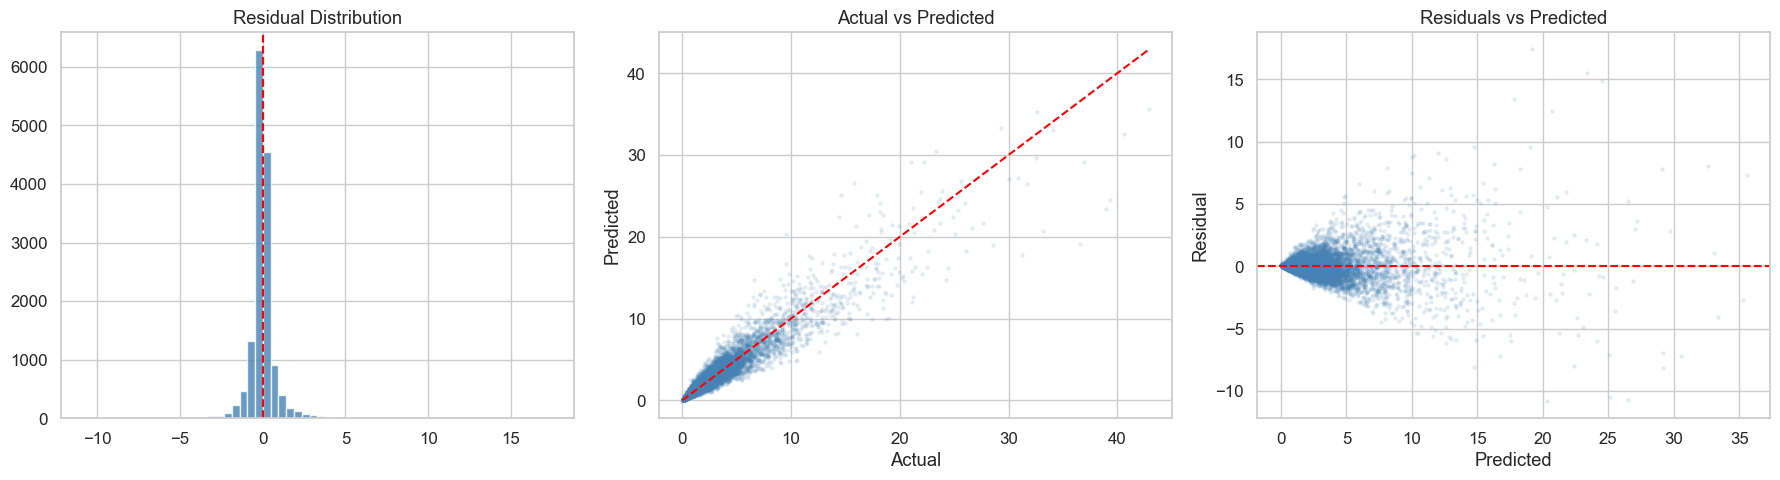

Mean Residual: -0.0093
Std Residual:  0.9110


In [27]:
# 4.2 Residual Analysis
y_pred_val = xgb.predict(X_val)
residuals = y_val - y_pred_val

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual distribution
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Residual Distribution')
axes[0].axvline(0, color='red', ls='--')

# Predicted vs Actual
axes[1].scatter(y_val, y_pred_val, alpha=0.1, s=5, c='steelblue')
axes[1].plot([0, y_val.max()], [0, y_val.max()], 'r--', lw=1.5)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted')

# Residuals vs Predicted
axes[2].scatter(y_pred_val, residuals, alpha=0.1, s=5, c='steelblue')
axes[2].axhline(0, color='red', ls='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual:  {residuals.std():.4f}")

## 5. Final Model — Training & Saving

In [28]:
# 5.1 Train final model on train set, evaluate on val & test
final_model = xgb  # Use the best tuned XGBoost

print("=== Final Model Performance ===")
print("\nValidation Set:")
evaluate_model('Final XGBoost (val)', y_val, final_model.predict(X_val))
print("\nTest Set:")
evaluate_model('Final XGBoost (test)', y_test, final_model.predict(X_test))

=== Final Model Performance ===

Validation Set:
  Final XGBoost (val)       | MAE: 0.4617 | RMSE: 0.9110 | R²: 0.8990 | MAPE: 22.62%

Test Set:
  Final XGBoost (test)      | MAE: 0.4746 | RMSE: 0.9838 | R²: 0.8873 | MAPE: 22.83%


{'model': 'Final XGBoost (test)',
 'MAE': 0.4746361387234099,
 'RMSE': np.float64(0.9838295761877681),
 'R2': 0.8873319170178459,
 'MAPE': np.float64(22.8309284974355)}

In [29]:
# 5.2 Save model, scaler, and predictions
joblib.dump(final_model, 'xgboost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

# Save predictions
test_predictions = pd.DataFrame({
    'actual': y_test.values,
    'predicted': final_model.predict(X_test),
    'residual': y_test.values - final_model.predict(X_test)
})
test_predictions.to_csv('test_predictions.csv', index=False)

val_predictions = pd.DataFrame({
    'actual': y_val.values,
    'predicted': final_model.predict(X_val),
    'residual': y_val.values - final_model.predict(X_val)
})
val_predictions.to_csv('val_predictions.csv', index=False)

print("✅ Model saved: xgboost_model.pkl")
print("✅ Predictions saved: test_predictions.csv, val_predictions.csv")

✅ Model saved: xgboost_model.pkl
✅ Predictions saved: test_predictions.csv, val_predictions.csv


## 6. Findings 

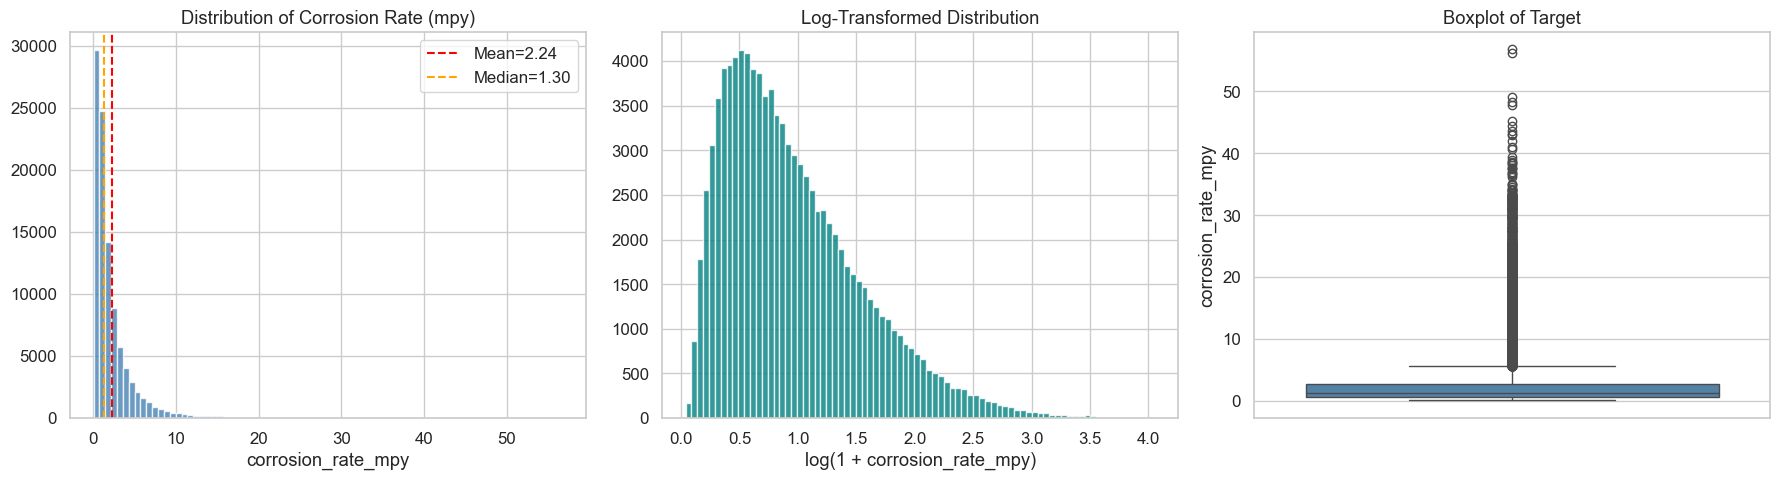

Skewness: 4.335
Kurtosis: 31.539


In [30]:
# 6.1 Target Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['corrosion_rate_mpy'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Corrosion Rate (mpy)')
axes[0].set_xlabel('corrosion_rate_mpy')
axes[0].axvline(df['corrosion_rate_mpy'].mean(), color='red', ls='--', label=f"Mean={df['corrosion_rate_mpy'].mean():.2f}")
axes[0].axvline(df['corrosion_rate_mpy'].median(), color='orange', ls='--', label=f"Median={df['corrosion_rate_mpy'].median():.2f}")
axes[0].legend()

axes[1].hist(np.log1p(df['corrosion_rate_mpy']), bins=80, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('log(1 + corrosion_rate_mpy)')

sns.boxplot(y=df['corrosion_rate_mpy'], ax=axes[2], color='steelblue')
axes[2].set_title('Boxplot of Target')

plt.tight_layout()
plt.show()
print(f"Skewness: {df['corrosion_rate_mpy'].skew():.3f}")
print(f"Kurtosis: {df['corrosion_rate_mpy'].kurtosis():.3f}")

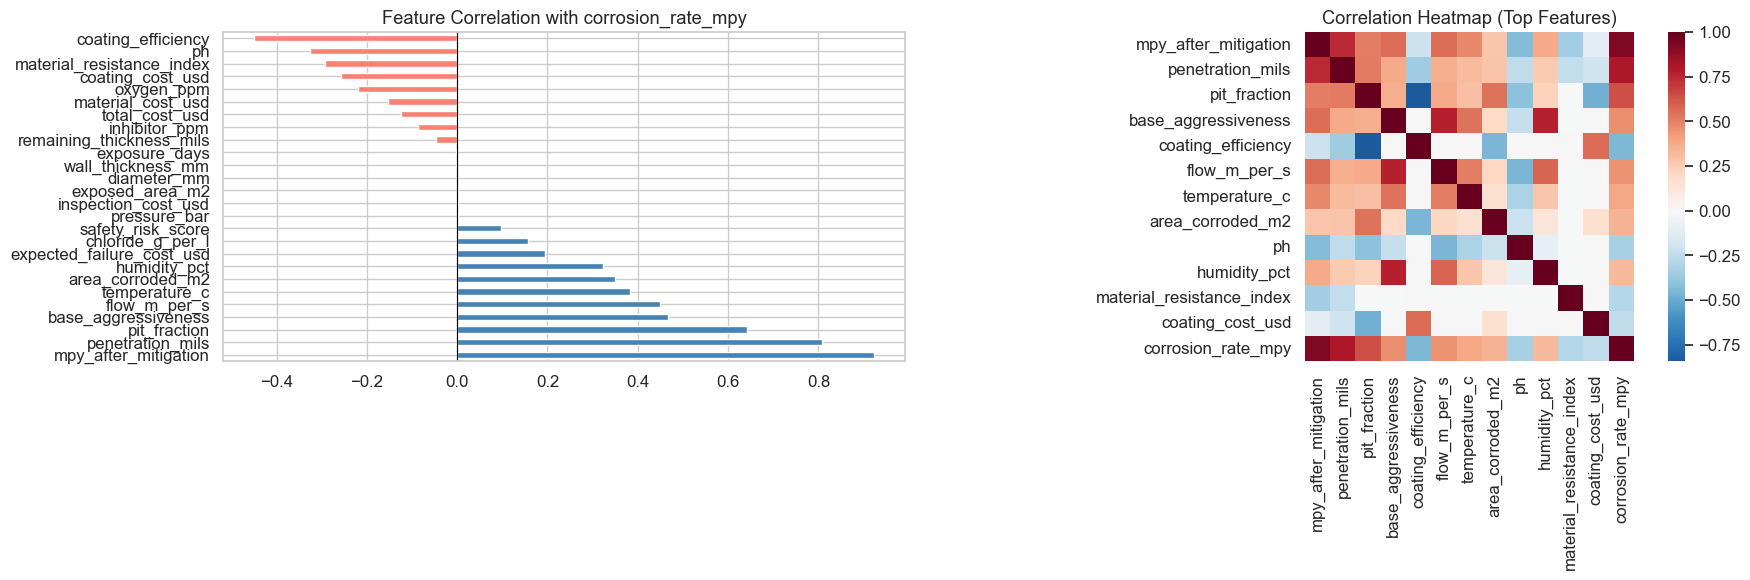

In [31]:
# 6.2 Correlation Analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

# Correlation with target
target_corr = corr['corrosion_rate_mpy'].drop('corrosion_rate_mpy').sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

target_corr.plot(kind='barh', ax=axes[0], color=['steelblue' if v > 0 else 'salmon' for v in target_corr])
axes[0].set_title('Feature Correlation with corrosion_rate_mpy')
axes[0].axvline(0, color='black', lw=0.8)

# Heatmap of top features
top_feats = target_corr.abs().nlargest(12).index.tolist() + ['corrosion_rate_mpy']
sns.heatmap(df[top_feats].corr(), fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1], square=True)
axes[1].set_title('Correlation Heatmap (Top Features)')

plt.tight_layout()
plt.show()

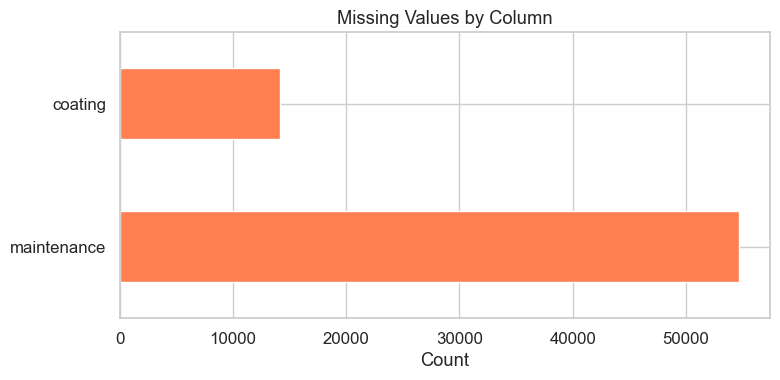

In [32]:
# 6.3 Missing Value Analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
missing.plot(kind='barh', color='coral', ax=ax)
ax.set_title('Missing Values by Column')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

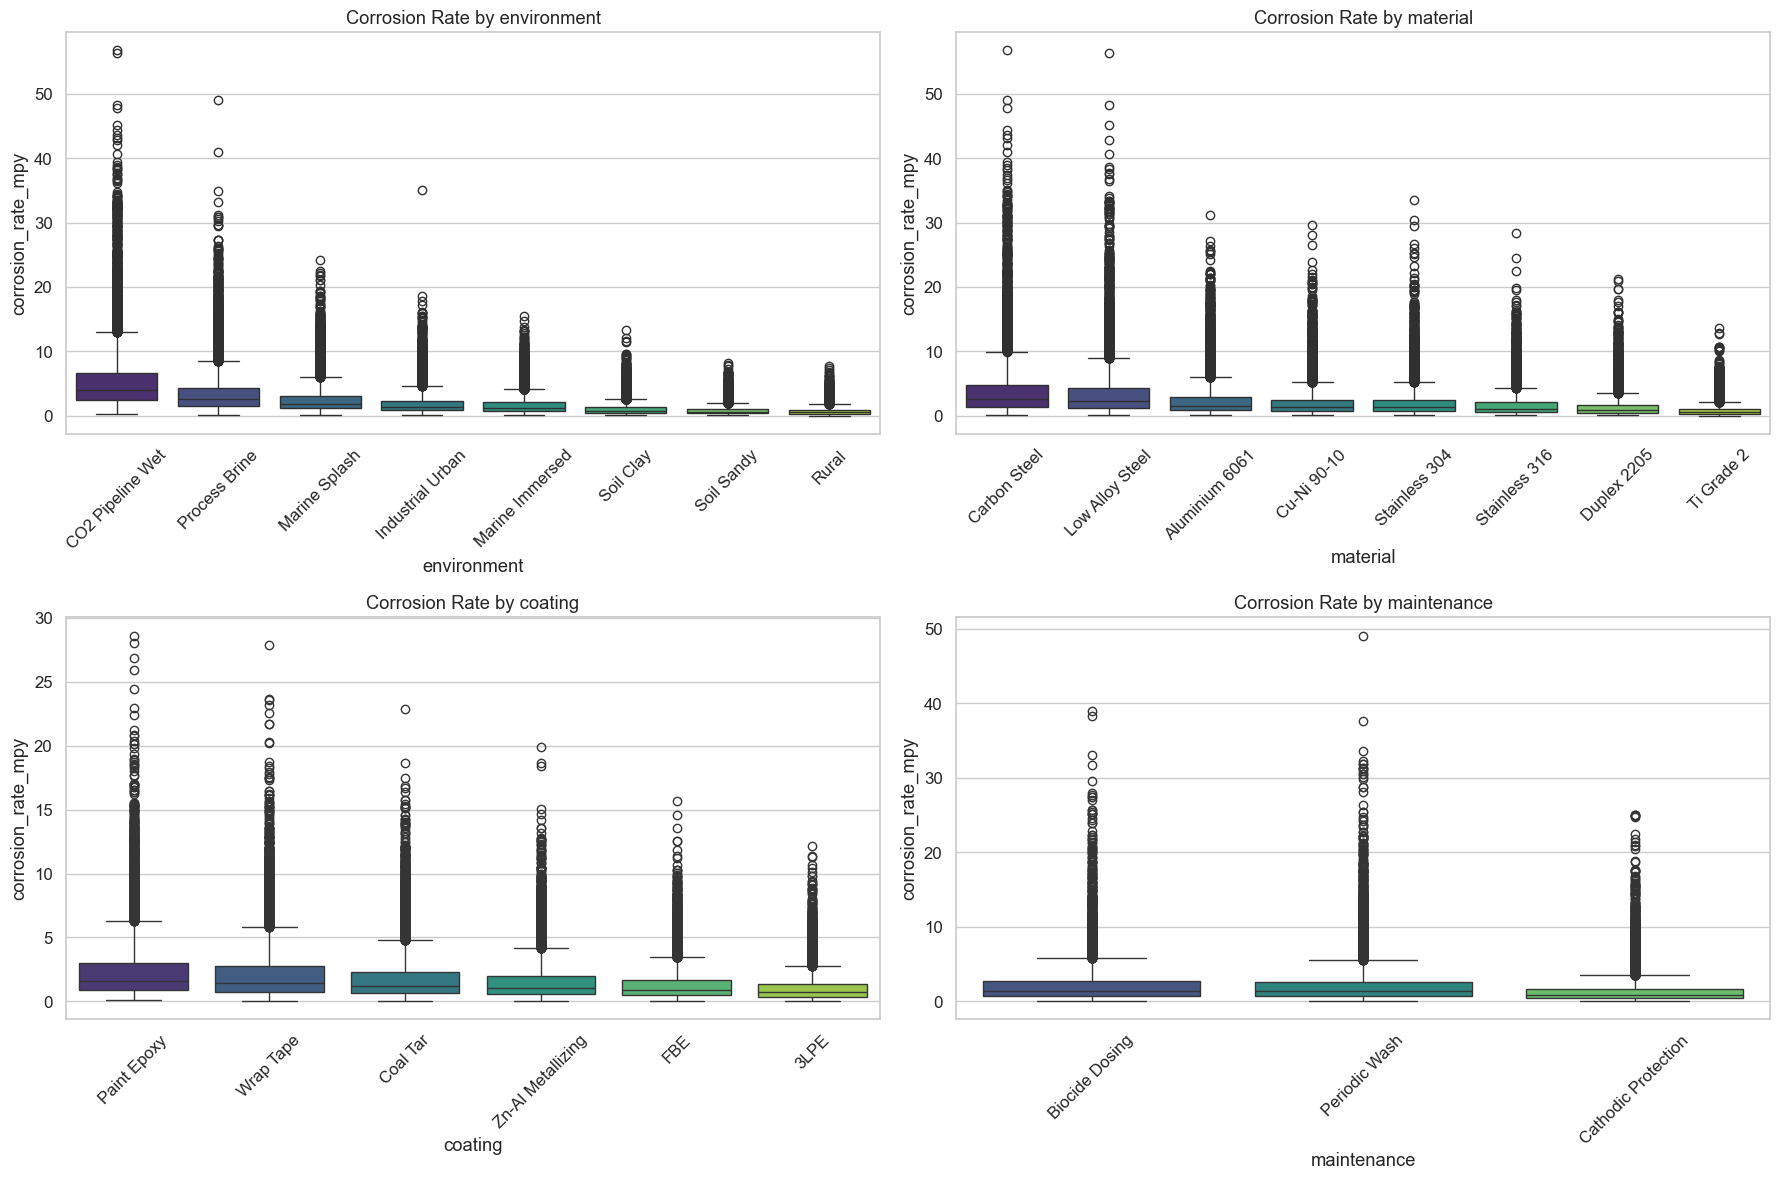

In [33]:
# 6.4 Categorical Features Analysis
cat_cols = ['environment', 'material', 'coating', 'maintenance']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.flat, cat_cols):
    order = df.groupby(col)['corrosion_rate_mpy'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='corrosion_rate_mpy', ax=ax, order=order, palette='viridis')
    ax.set_title(f'Corrosion Rate by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

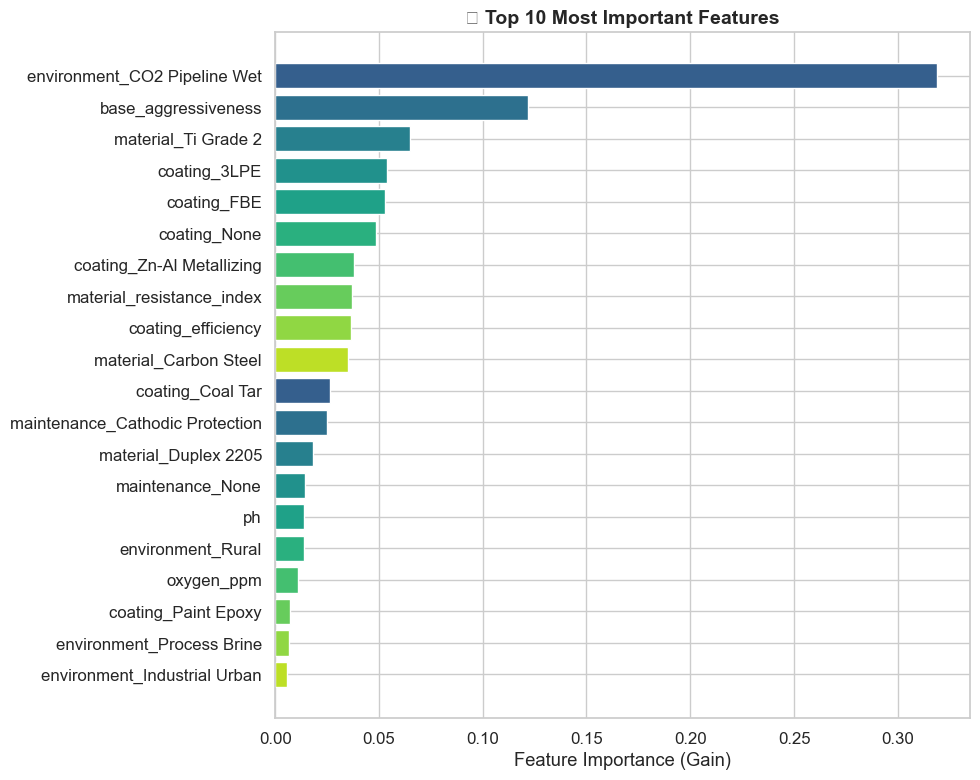

In [39]:
# 6.5 Top 20 Most Important Features
importances = xgb.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
ax.set_title('🔝 Top 10 Most Important Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

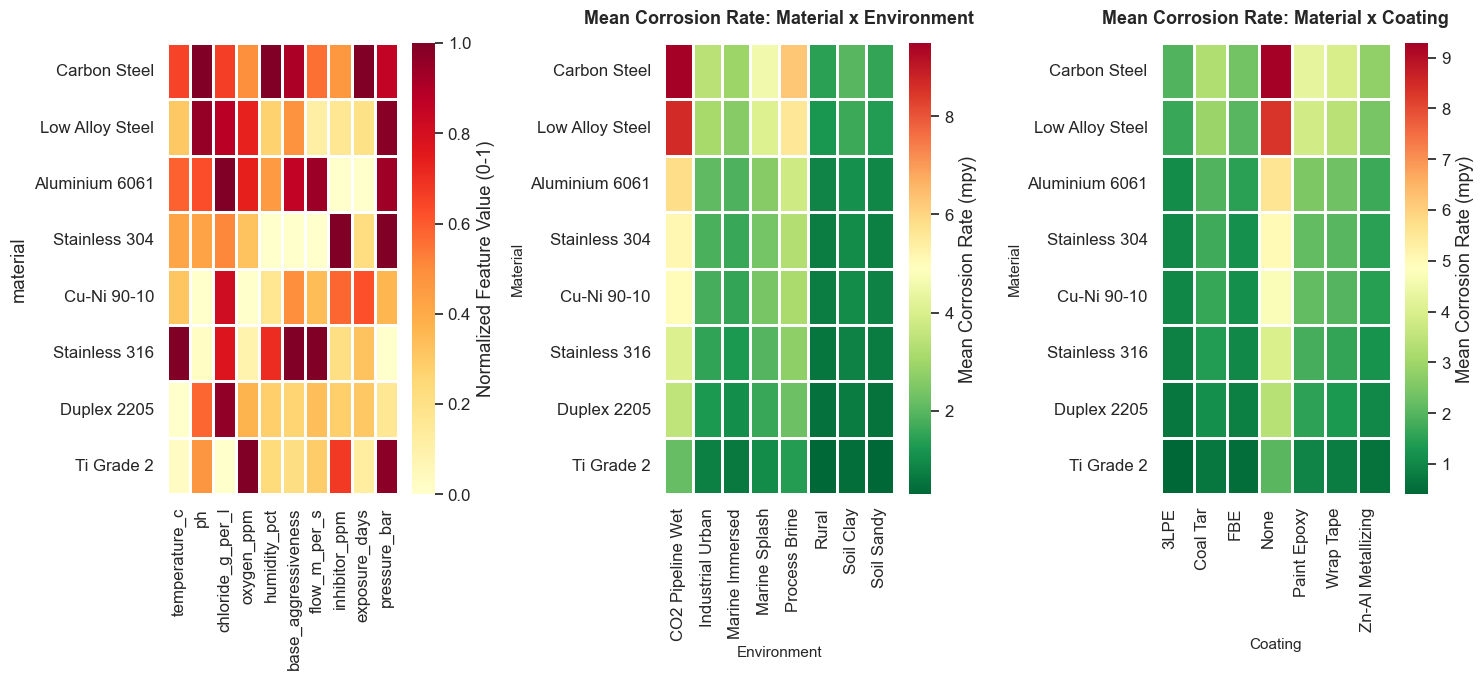

In [20]:
# Heatmap 1: Material x Key Features (normalized, annotated with real values)
features = [
    'temperature_c', 'ph', 'chloride_g_per_l', 'oxygen_ppm',
    'humidity_pct', 'base_aggressiveness', 'flow_m_per_s',
    'inhibitor_ppm', 'exposure_days', 'pressure_bar'
]

mat_feat = df.groupby('material')[features + ['corrosion_rate_mpy']].mean()
mat_feat = mat_feat.sort_values('corrosion_rate_mpy', ascending=False)

mean_corr = mat_feat['corrosion_rate_mpy']
mat_feat_norm = mat_feat.drop('corrosion_rate_mpy', axis=1)
mat_feat_scaled = (mat_feat_norm - mat_feat_norm.min()) / (mat_feat_norm.max() - mat_feat_norm.min())

fig, axes = plt.subplots(1,3,figsize=(15, 7))
sns.heatmap(
    mat_feat_scaled,  fmt='',
    cmap='YlOrRd', linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Normalized Feature Value (0-1)'}, ax=axes[0]
)
# Annotate mean corrosion rate on the right
for i, (mat, rate) in enumerate(mean_corr.items()):
    ax.text(len(features) + 0.3, i + 0.5, f'{rate:.2f} mpy',
            va='center', fontsize=10, fontweight='bold', color='#d62728')

ax.set_title('Mean Feature Values per Material  (sorted by corrosion rate, mpy shown in red)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Features', fontsize=11)
ax.set_ylabel('Material', fontsize=11)
plt.xticks(rotation=30, ha='right')

# Heatmap 2: Material x Environment - Mean Corrosion Rate
pivot_env = df.pivot_table(
    values='corrosion_rate_mpy',
    index='material',
    columns='environment',
    aggfunc='mean'
)
pivot_env = pivot_env.loc[pivot_env.mean(axis=1).sort_values(ascending=False).index]

sns.heatmap(
    pivot_env, fmt='.2f', cmap='RdYlGn_r',
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Mean Corrosion Rate (mpy)'}, ax=axes[1]
)
axes[1].set_title('Mean Corrosion Rate: Material x Environment',
             fontsize=13, fontweight='bold', pad=14)
axes[1].set_xlabel('Environment', fontsize=11)
axes[1].set_ylabel('Material', fontsize=11)
plt.xticks(rotation=30, ha='right')

# Heatmap 3: Material x Coating - Mean Corrosion Rate
df['coating_filled'] = df['coating'].fillna('None')

pivot_coat = df.pivot_table(
    values='corrosion_rate_mpy',
    index='material',
    columns='coating_filled',
    aggfunc='mean'
)
pivot_coat = pivot_coat.loc[pivot_coat.mean(axis=1).sort_values(ascending=False).index]

sns.heatmap(
    pivot_coat, fmt='.2f', cmap='RdYlGn_r',
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Mean Corrosion Rate (mpy)'}, ax=axes[2]
)
axes[2].set_title('Mean Corrosion Rate: Material x Coating',
             fontsize=13, fontweight='bold', pad=14)
axes[2].set_xlabel('Coating', fontsize=11)
axes[2].set_ylabel('Material', fontsize=11)
plt.tight_layout()
plt.show()

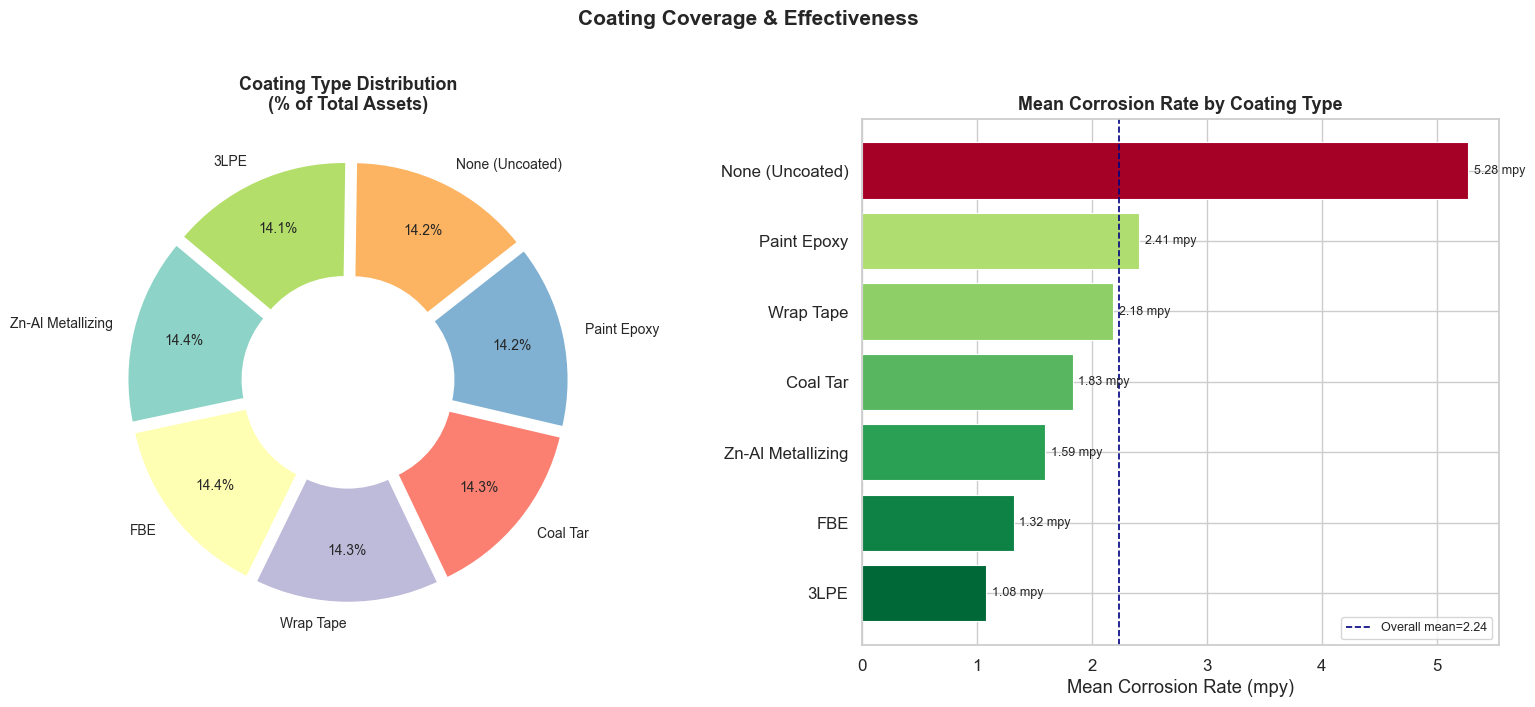

Uncoated assets: 14,183 (14.2%)
Uncoated mean corrosion: 5.28 mpy
Best coating (3LPE) mean: 1.08 mpy


In [21]:
# Pie 1: Coating Type Distribution (including None)
df_pie = df.copy()
df_pie['coating'] = df_pie['coating'].fillna('None (Uncoated)')

coating_counts = df_pie['coating'].value_counts()
explode = [0.05] * len(coating_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
colors = plt.cm.Set3.colors[:len(coating_counts)]

axes[0].pie(coating_counts, labels=coating_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors, explode=explode,
            wedgeprops=wedge_props, pctdistance=0.75, textprops={'fontsize': 10})
axes[0].set_title('Coating Type Distribution\n(% of Total Assets)', fontsize=13, fontweight='bold')

# Mean corrosion rate per coating type
mean_corr_coat = df_pie.groupby('coating')['corrosion_rate_mpy'].mean().sort_values(ascending=True)
bars = axes[1].barh(mean_corr_coat.index, mean_corr_coat.values,
                     color=plt.cm.RdYlGn_r(
                         (mean_corr_coat.values - mean_corr_coat.min()) /
                         (mean_corr_coat.max() - mean_corr_coat.min())
                     ), edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mean_corr_coat.values):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} mpy', va='center', fontsize=9)
axes[1].set_title('Mean Corrosion Rate by Coating Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Corrosion Rate (mpy)')
axes[1].axvline(df['corrosion_rate_mpy'].mean(), color='navy', ls='--', lw=1.2, label=f'Overall mean={df["corrosion_rate_mpy"].mean():.2f}')
axes[1].legend(fontsize=9)

plt.suptitle('Coating Coverage & Effectiveness', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Uncoated assets: {(df_pie['coating']=='None (Uncoated)').sum():,} ({(df_pie['coating']=='None (Uncoated)').mean()*100:.1f}%)")
print(f"Uncoated mean corrosion: {df_pie[df_pie['coating']=='None (Uncoated)']['corrosion_rate_mpy'].mean():.2f} mpy")
print(f"Best coating (3LPE) mean: {df_pie[df_pie['coating']=='3LPE']['corrosion_rate_mpy'].mean():.2f} mpy")

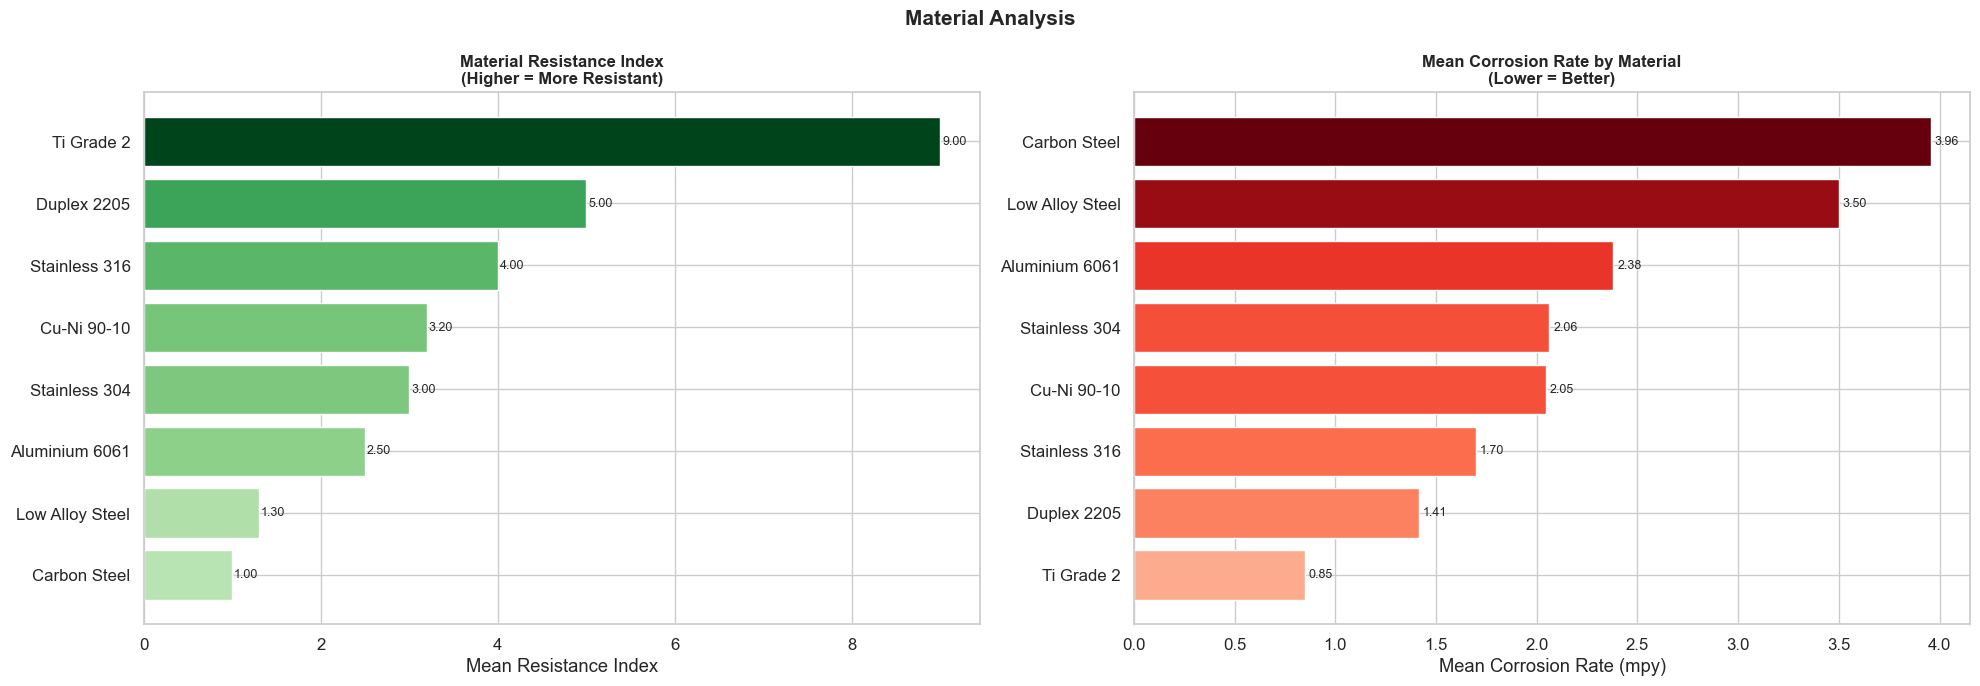

In [22]:
# Pie 3: Material Distribution + Resistance Index
mat_counts = df['material'].value_counts()
mat_resist = df.groupby('material')['material_resistance_index'].mean().sort_values(ascending=False)
mat_corr   = df.groupby('material')['corrosion_rate_mpy'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))


# Bar — resistance index
colors_r = plt.cm.Greens(
    (mat_resist.values - mat_resist.min()) / (mat_resist.max() - mat_resist.min()) * 0.7 + 0.3
)
bars = axes[0].barh(mat_resist.index[::-1], mat_resist.values[::-1],
                    color=colors_r[::-1], edgecolor='white')
axes[0].set_title('Material Resistance Index\n(Higher = More Resistant)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Resistance Index')
for bar, val in zip(bars, mat_resist.values[::-1]):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

# Bar — mean corrosion
colors_c = plt.cm.Reds(
    (mat_corr.values - mat_corr.min()) / (mat_corr.max() - mat_corr.min()) * 0.7 + 0.3
)
bars2 = axes[1].barh(mat_corr.index[::-1], mat_corr.values[::-1],
                     color=colors_c[::-1], edgecolor='white')
axes[1].set_title('Mean Corrosion Rate by Material\n(Lower = Better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Corrosion Rate (mpy)')
for bar, val in zip(bars2, mat_corr.values[::-1]):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Material Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

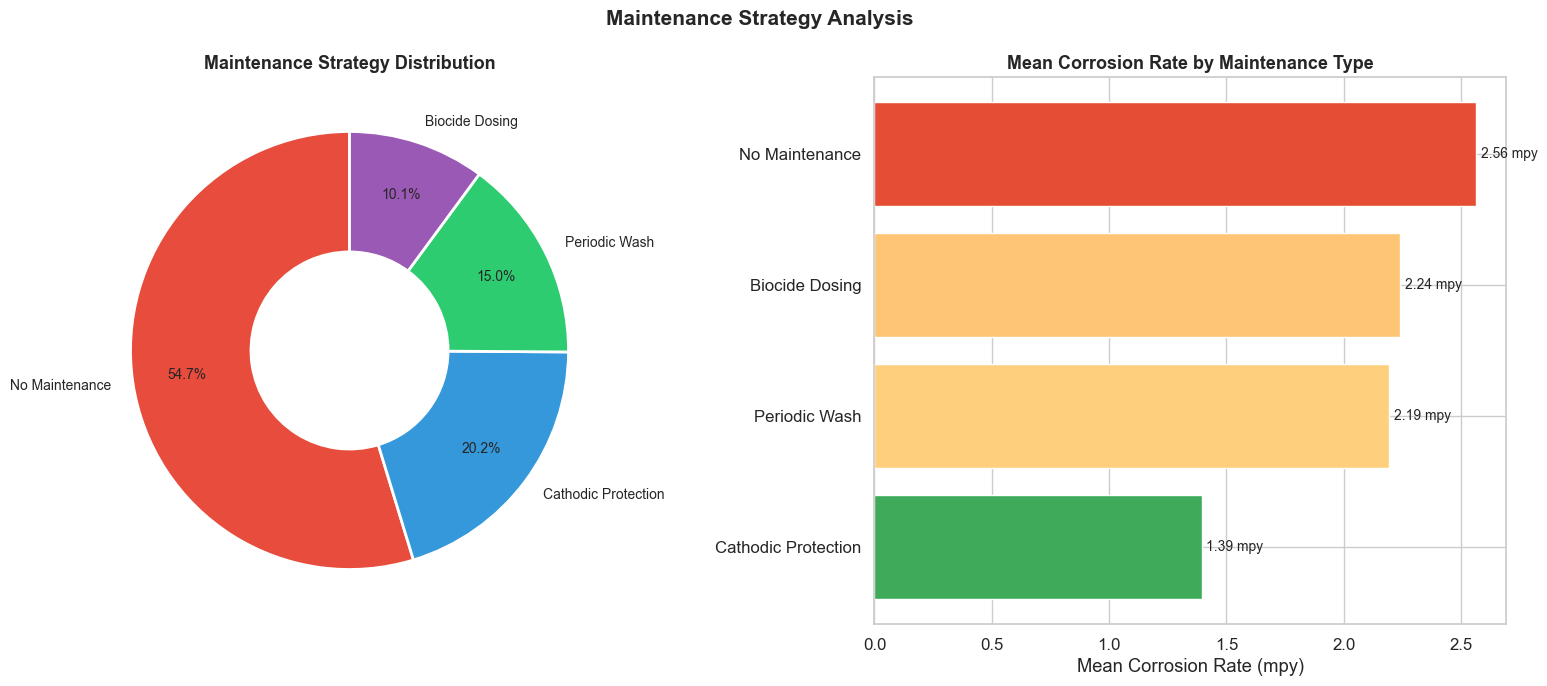

In [23]:
# Pie 5: Maintenance Type Distribution & Impact
df_m = df.copy()
df_m['maintenance_cat'] = df_m['maintenance'].fillna(0)
df_m['maint_label'] = df_m['maintenance'].apply(
    lambda x: 'Cathodic Protection' if x == 1.0
    else ('Periodic Wash' if x == 2.0
    else ('Biocide Dosing' if x == 3.0 else 'No Maintenance'))
    if not pd.isna(x) else 'No Maintenance'
)

# Handle string values in maintenance column
df_m2 = df.copy()
df_m2['maint_label'] = df_m2['maintenance'].fillna('No Maintenance').astype(str)
maint_counts = df_m2['maint_label'].value_counts()
maint_corr   = df_m2.groupby('maint_label')['corrosion_rate_mpy'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_maint = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6'][:len(maint_counts)]
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)

axes[0].pie(maint_counts, labels=maint_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors_maint, wedgeprops=wedge_props,
            pctdistance=0.75, textprops={'fontsize': 10})
axes[0].set_title('Maintenance Strategy Distribution', fontsize=13, fontweight='bold')

bars = axes[1].barh(maint_corr.index, maint_corr.values,
                     color=plt.cm.RdYlGn_r(
                         (maint_corr.values - maint_corr.min()) /
                         (maint_corr.max() - maint_corr.min()) * 0.7 + 0.15
                     ), edgecolor='white')
for bar, val in zip(bars, maint_corr.values):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} mpy', va='center', fontsize=10)
axes[1].set_title('Mean Corrosion Rate by Maintenance Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Corrosion Rate (mpy)')

plt.suptitle('Maintenance Strategy Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

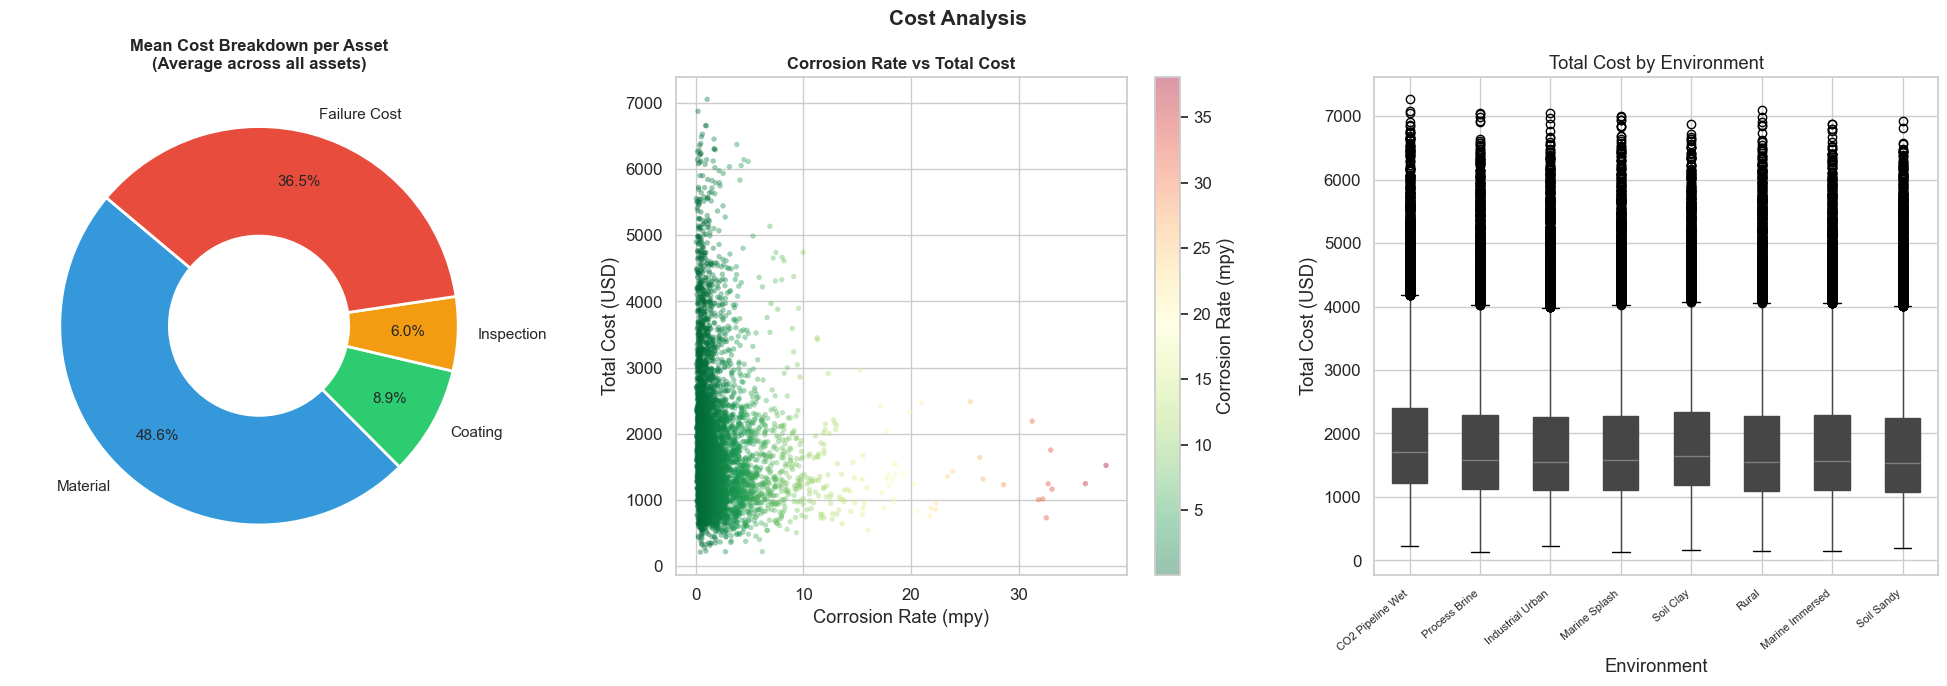

In [40]:
# Cost Analysis: Total cost breakdown and corrosion rate vs cost
cost_cols = ['material_cost_usd', 'coating_cost_usd',
             'inspection_cost_usd', 'expected_failure_cost_usd']
cost_means = df[cost_cols].mean()
cost_labels = ['Material', 'Coating', 'Inspection', 'Failure Cost']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Donut — cost breakdown
colors_cost = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[0].pie(cost_means, labels=cost_labels, autopct='%1.1f%%',
            startangle=140, colors=colors_cost, wedgeprops=wedge_props,
            pctdistance=0.75, textprops={'fontsize': 11})
axes[0].set_title('Mean Cost Breakdown per Asset\n(Average across all assets)',
                  fontsize=12, fontweight='bold')

# Scatter: corrosion_rate vs total_cost
sample = df.sample(5000, random_state=42)
sc = axes[1].scatter(sample['corrosion_rate_mpy'], sample['total_cost_usd'],
                     c=sample['corrosion_rate_mpy'], cmap='RdYlGn_r',
                     alpha=0.4, s=15, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Corrosion Rate (mpy)')
axes[1].set_xlabel('Corrosion Rate (mpy)')
axes[1].set_ylabel('Total Cost (USD)')
axes[1].set_title('Corrosion Rate vs Total Cost', fontsize=12, fontweight='bold')

# Box: total_cost by environment
env_order = df.groupby('environment')['total_cost_usd'].median().sort_values(ascending=False).index
df.boxplot(column='total_cost_usd', by='environment', ax=axes[2],
           patch_artist=True, vert=True)
axes[2].set_xticklabels(
    [df.groupby('environment')['total_cost_usd'].median().sort_values(ascending=False).index[i]
     for i in range(len(df['environment'].unique()))],
    rotation=40, ha='right', fontsize=8)
axes[2].set_title('Total Cost Distribution by Environment', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Environment')
axes[2].set_ylabel('Total Cost (USD)')
plt.sca(axes[2]); plt.title('Total Cost by Environment')

plt.suptitle('Cost Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Exploratory Feature Analysis (Non-Target Graphs)

This section explores relationships between features, distributions, and grouped analyses
that go beyond just the `corrosion_rate_mpy` target variable.

In [ ]:
# Graph 1: Exposed Area Bins vs Mean Corrosion Rate by Material
# Shows how physical size of exposed area interacts with material type

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create area bins
df['area_bin'] = pd.cut(df['exposed_area_m2'], bins=4, labels=['Small', 'Medium', 'Large', 'Very Large'])

# Get top 5 materials by count
top_materials = df['material'].value_counts().head(5).index.tolist()

# Filter for top materials
df_top = df[df['material'].isin(top_materials)]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

pivot_data = df_top.groupby(['area_bin', 'material'], observed=False)['corrosion_rate_mpy'].mean().unstack()
pivot_data.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')

ax.set_title('Exposed Area Bins vs Mean Corrosion Rate by Material', fontsize=14, fontweight='bold')
ax.set_xlabel('Exposed Area Bin', fontsize=12)
ax.set_ylabel('Mean Corrosion Rate (MPY)', fontsize=12)
ax.legend(title='Material', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Graph 2: Mean Corrosion Rate by Material (Top 5 Feature Importance Context)
# Shows how corrosion rate varies across different materials

material_rates = df.groupby('material')['corrosion_rate_mpy'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(material_rates)))
bars = ax.barh(material_rates.index, material_rates.values, color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, material_rates.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Mean Corrosion Rate by Material Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Corrosion Rate (MPY)', fontsize=12)
ax.set_ylabel('Material', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
# Graph 3: Environment Type Distribution & Mean Corrosion Rate
# Dual-panel chart showing distribution and severity

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Pie chart of environment distribution
env_counts = df['environment'].value_counts()
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(env_counts)))
ax1.pie(env_counts.values, labels=env_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, textprops={'fontsize': 9})
ax1.set_title('Environment Type Distribution', fontsize=13, fontweight='bold')

# Right: Horizontal bar chart of mean corrosion rate by environment
env_rate = df.groupby('environment')['corrosion_rate_mpy'].mean().sort_values(ascending=True)
colors_bar = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(env_rate)))
bars = ax2.barh(env_rate.index, env_rate.values, color=colors_bar, edgecolor='white', height=0.6)

for bar, val in zip(bars, env_rate.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=10, fontweight='bold')

ax2.set_title('Mean Corrosion Rate by Environment', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mean Corrosion Rate (MPY)', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Environment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Graph 4: Exposure Days vs Corrosion Rate (colored by Environment)
# Shows temporal relationship between exposure time and corrosion

fig, ax = plt.subplots(figsize=(14, 7))

environments = df['environment'].unique()
colors_scatter = plt.cm.tab10(np.linspace(0, 1, len(environments)))

# Sample 500 points per environment for performance
for env, color in zip(environments, colors_scatter):
    subset = df[df['environment'] == env].sample(n=min(500, len(df[df['environment'] == env])), random_state=42)
    ax.scatter(subset['exposure_days'], subset['corrosion_rate_mpy'],
              c=[color], label=env, alpha=0.5, s=15, edgecolors='none')

ax.set_title('Exposure Days vs Corrosion Rate by Environment', fontsize=14, fontweight='bold')
ax.set_xlabel('Exposure Days', fontsize=12)
ax.set_ylabel('Corrosion Rate (MPY)', fontsize=12)
ax.legend(title='Environment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
# Graph 5: Feature Distribution Boxplots
# Boxplots of key numerical features to show distributions

box_features = ['temperature_c', 'ph', 'chloride_g_per_l', 'oxygen_ppm', 'flow_m_per_s', 'humidity_pct']
feature_labels = ['Temperature (C)', 'pH', 'Chloride (g/L)', 'Oxygen (ppm)', 'Flow (m/s)', 'Humidity (%)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, len(box_features)))

for idx, (feat, label) in enumerate(zip(box_features, feature_labels)):
    bp = axes[idx].boxplot(df[feat].dropna(), patch_artist=True, vert=True,
                           boxprops=dict(facecolor=colors[idx], alpha=0.7),
                           medianprops=dict(color='black', linewidth=2))
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    
    # Add mean annotation
    mean_val = df[feat].mean()
    axes[idx].axhline(y=mean_val, color='red', linestyle='--', alpha=0.7, linewidth=1)
    axes[idx].text(1.15, mean_val, f'Mean: {mean_val:.1f}', va='center', fontsize=8, color='red')

plt.suptitle('Key Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
